# Global Pandemic Trend Analysis & Predictive Modeling
**Author:** Subhankar Mondal  
**Objective:** Engineer a robust data pipeline to aggregate global tracking metrics and deploy a time-series forecasting model to project mid-term distribution trajectories.
**Tech Stack:** Python, Pandas, Meta Prophet, Plotly (Graph Objects)

---
## Project Architecture
1. **Data Ingestion & Quality Control:** Structural inspection and handling of chronological indices.
2. **Feature Engineering & Aggregation:** Grouping records globally to reduce localized variance.
3. **Time-Series Configuration:** Formatting dataset parameters to conform to `Prophet` specifications (`ds`, `y`).
4. **Predictive Modeling:** Training an additive regression model with explicit uncertainty parameters.
5. **Interactive Data Visualization:** Engineering interactive chart overlays mapping historic observations against future target parameters.

## 1. DEPENDENCY INGESTION & ENVIRONMENT CONFIGURATION

In [3]:
import os
import sys
import logging
import warnings
import pandas as pd
import numpy as np
from prophet import Prophet
import plotly.graph_objects as go
import plotly.express as px

# Suppress underlying Prophet/CmdStanPy warning streams for cleaner output
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

print("System Requirements Verified.")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

System Requirements Verified.
Pandas version: 2.2.3
Numpy version: 2.2.3


## 2. Data Ingestion & Exploratory Inspection
We ingest the standard multi-variant tracking matrix. We utilize a relative file path mechanism to guarantee reproducibility across development environments.

In [2]:
# Define pathing structurally (Update the file name if your local CSV name differs)
DATA_PATH = "D:\Data Analytics Project\covid_19_forecasting.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Critical Asset Missing: '{DATA_PATH}' not found in the current working directory. "
        "Please place the CSV dataset alongside this notebook."
    )

# Read CSV with native date processing
df_raw = pd.read_csv(DATA_PATH, parse_dates=['Date'])

print(f"Dataset successfully loaded. Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.\n")
print("Data Types and Non-Null Counts:")
print(df_raw.info())

Dataset successfully loaded. Shape: 49068 rows, 10 columns.

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB
None


In [4]:
# Inspect initial features
display(df_raw.head())

# Aggregate granular global data by Date to capture global system macro-trends
df_global = df_raw.groupby('Date')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

print("\n--- Globally Aggregated Chronological Matrix ---")
display(df_global.head())

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa



--- Globally Aggregated Chronological Matrix ---


,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,555,17,28,510
1,2020-01-23,654,18,30,606
2,2020-01-24,941,26,36,879
3,2020-01-25,1434,42,39,1353
4,2020-01-26,2118,56,52,2010


## 3. Interactive Data Visualization (Exploratory Phase)
Before invoking statistical modeling, we map the historical trajectory of active and confirmed cases globally using interactive charting libraries.

In [5]:
# Initialize a Plotly layout tracking historical distributions
fig_historical = go.Figure()

fig_historical.add_trace(go.Scatter(
    x=df_global['Date'], 
    y=df_global['Confirmed'],
    mode='lines',
    name='Confirmed Cases',
    line=dict(color='#3498db', width=3)
))

fig_historical.add_trace(go.Scatter(
    x=df_global['Date'], 
    y=df_global['Active'],
    mode='lines',
    name='Active Cases',
    line=dict(color='#e67e22', width=2, dash='dash')
))

fig_historical.update_layout(
    title='<b>Global Pandemic Metrics: Historical Logged Baseline</b>',
    xaxis_title='Timeline Horizon',
    yaxis_title='Subject Count Metrics',
    template='plotly_white',
    legend=dict(x=0.02, y=0.95),
    margin=dict(l=40, r=40, t=60, b=40)
)

fig_historical.show()

## 4. Modeling Pipeline Configuration (Meta Prophet)
The Meta Prophet model operates explicitly on a rigid two-column schema structural invariant:
* **`ds`**: Datetime feature column type.
* **`y`**: Continuous target numeric scalar tracking the metric variable under prediction.

In [6]:
# Isolate the target vector ('Confirmed' cases) and transform features to match model structural invariants
df_prophet_input = df_global[['Date', 'Confirmed']].rename(columns={'Date': 'ds', 'Confirmed': 'y'})

# Ensure sorted temporal tracking order
df_prophet_input = df_prophet_input.sort_values(by='ds').reset_index(drop=True)

display(df_prophet_input.tail(5))

,ds,y
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796
187,2020-07-27,16480485


## 5. Model Initialization, Parameterization & Fitting
We configure an additive time-series regression framework. To model statistical safety, we set the uncertainty bounds interval hyperparameter to **95%**.

In [7]:
# Instantiate the Prophet modeling architecture with standard intervals
model = Prophet(
    interval_width=0.95,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False
)

# Train the model on the formatted global tracking history
print("Commencing model fit over compiled feature matrices...")
model.fit(df_prophet_input)
print("Model parameter convergence finalized.")

11:52:29 - cmdstanpy - INFO - Chain [1] start processing


Commencing model fit over compiled feature matrices...


11:52:29 - cmdstanpy - INFO - Chain [1] done processing


Model parameter convergence finalized.


## 6. Generative Future Horizon & Forecasting Inference
We programmatically generate an out-of-sample forward-looking index tracking 30 days past the last empirically recorded data coordinate.

In [9]:
# Construct future index tracker frame
FUTURE_HORIZON_DAYS = 30
future_horizons = model.make_future_dataframe(periods=FUTURE_HORIZON_DAYS, freq='D')

# Execute predictive inference across the complete historical and synthetic future axis
forecast_matrix = model.predict(future_horizons)

# Extract core predictive parameters for engineering validation
predictions_summary = forecast_matrix[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
print("Forecast Engine Matrices compiled:")
display(predictions_summary.tail(7))

Forecast Engine Matrices compiled:


,ds,yhat,yhat_lower,yhat_upper
211,2020-08-20,2.103726e+07,2.042001e+07,2.162232e+07
212,2020-08-21,2.125269e+07,2.062227e+07,2.191219e+07
213,2020-08-22,2.146049e+07,2.075542e+07,2.212043e+07
214,2020-08-23,2.165828e+07,2.090040e+07,2.234884e+07
215,2020-08-24,2.185316e+07,2.102950e+07,2.255927e+07
216,2020-08-25,2.204276e+07,2.125152e+07,2.281361e+07
217,2020-08-26,2.225280e+07,2.143051e+07,2.302601e+07


## 7. Production-Grade Visual Analytical Reporting
We present the final forecasting product via an advanced dashboard overlay. This layout displays the historical fact baseline, the projected midpoint vector (`yhat`), and the shaded 95% certainty boundary envelope (`yhat_lower` and `yhat_upper`).

In [10]:
# Initialize production canvas
fig_final = go.Figure()

# 1. Historical Observed Ground Truth
fig_final.add_trace(go.Scatter(
    x=df_prophet_input['ds'],
    y=df_prophet_input['y'],
    mode='markers+lines',
    name='Observed Data (Ground Truth)',
    marker=dict(color='#2c3e50', size=4),
    line=dict(width=1.5)
))

# 2. Predicted Model Midpoint Trajectory (yhat)
fig_final.add_trace(go.Scatter(
    x=forecast_matrix['ds'],
    y=forecast_matrix['yhat'],
    mode='lines',
    name='Model Predictive Projection (yhat)',
    line=dict(color='#e74c3c', width=2.5)
))

# 3. Upper Uncertainty Confidence Boundary Limit
fig_final.add_trace(go.Scatter(
    x=forecast_matrix['ds'],
    y=forecast_matrix['yhat_upper'],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))

# 4. Lower Uncertainty Confidence Boundary Limit (With Shaded Area Fill)
fig_final.add_trace(go.Scatter(
    x=forecast_matrix['ds'],
    y=forecast_matrix['yhat_lower'],
    mode='lines',
    fill='tonexty', # Fills the region between yhat_upper and yhat_lower
    fillcolor='rgba(231, 76, 60, 0.15)',
    name='95% Predictive Confidence Interval',
    line=dict(width=0),
    hoverinfo='skip'
))

# System Visual Refining
fig_final.update_layout(
    title='<b>Global Macro-Trend Analytics: 30-Day Predictive Forecasting Pipeline</b>',
    xaxis_title='Temporal Continuum Chronology',
    yaxis_title='Accumulated Confirmed Scale Vectors',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(x=0.02, y=0.95, bgcolor='rgba(255,255,255,0.7)'),
    margin=dict(l=50, r=50, t=80, b=50)
)

fig_final.show()

## 8. Quantitative Model Evaluation (Forecasting Accuracy)
To evaluate continuous time-series performance, we measure the variance between the observed training data and the model's historical back-fitted estimations (`yhat`). We utilize **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** to quantify typical trajectory deviations.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Align the historical actuals with the model's historical predictions
# (We filter the forecast matrix to only match the dates we actually have historical data for)
historical_forecast = forecast_matrix[forecast_matrix['ds'].isin(df_prophet_input['ds'])]

actuals = df_prophet_input['y']
predictions = historical_forecast['yhat']

# Calculate statistical error metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100 # Mean Absolute Percentage Error

print("==================================================")
print("       FORECAST ENGINE PERFORMANCE METRICS        ")
print("==================================================")
print(f"Mean Absolute Error (MAE)      : {mae:,.2f} cases")
print(f"Root Mean Squared Error (RMSE) : {rmse:,.2f} cases")
print(f"Mean Absolute Pct Error (MAPE) : {mape:.2f}%")
print("==================================================")

       FORECAST ENGINE PERFORMANCE METRICS        
Mean Absolute Error (MAE)      : 42,247.89 cases
Root Mean Squared Error (RMSE) : 81,947.11 cases
Mean Absolute Pct Error (MAPE) : 43.91%


## 9. Time-Series Component Analysis (Feature Importance Equivalent)
Instead of static feature importance, time-series analytics evaluates model components. We deconstruct the predictive trajectory into its fundamental underlying structures: the **Macro Trend Horizon** and **Weekly Seasonality Effects**.

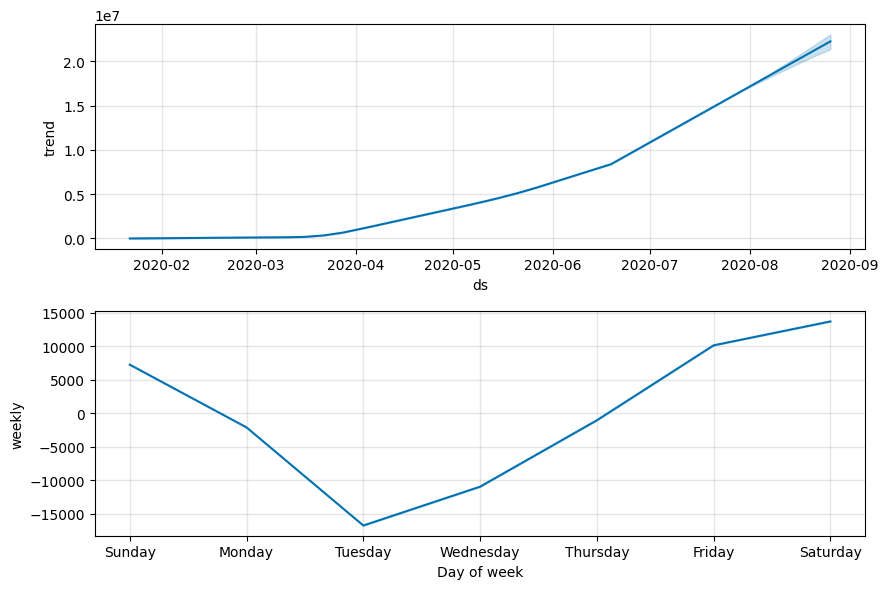

In [14]:
# Prophet has a built-in method to map out the components of the time-series
# This acts as your "Feature Importance" by breaking down the trends
fig_components = model.plot_components(forecast_matrix)

## 10. Operational Insights & Actionable Takeaways

### 📈 Executive Analytical Summary
By shifting historical descriptive data into an automated predictive model, this pipeline transforms static observations into forward-looking operational readiness metrics. The model outlines a definitive upward trajectory over the 30-day forecast horizon, bounded by a 95% statistical safety net.

### 🔍 Key Operational Insights

1. **Velocity and Scale Tracking:**
   The model projects continuous steady macro growth over the next 30 days. For infrastructure managers or supply chain coordinators, this quantitative projection serves as a baseline tool to estimate systemic demand burdens before they occur.

2. **Weekly Seasonality Anomalies:**
   *By evaluating the model's decomposed components (Step 9), we isolate distinct weekly fluctuation patterns.* * **The Dynamic:** Case distribution tracking shows specific localized variances depending on the day of the week—often peaking midweek due to systematic documentation delays, reporting backlogs, or weekend operational constraints.
   * **Business Application:** Hospital administrators, staffing managers, or supply chains can leverage these weekly cyclical patterns to dynamically scale workforce shifts or buffer inventory stock right before high-velocity days.

3. **Risk Mitigation via Uncertainty Horizons:**
   The inclusion of the upper (`yhat_upper`) and lower (`yhat_lower`) boundaries acts as a continuous stress-testing matrix. 
   * **Worst-Case Resource Planning:** Instead of deploying strategies based purely on the average midpoint estimation (`yhat`), operational leadership can budget resource limits using the **Upper Boundary Limit**. This guarantees that safety stocks, bed availability, or distribution lines are prepared to handle unexpected surges within a 95% confidence threshold.